# E-Commerce Sales Analysis Project

### Objective:
* **Analyzed 500K+ e-commerce transactions** using Python and Pandas to identify top revenue-driving products, seasonal trends, and regional sales performance.
* **Cleaned and preprocessed** raw transactional data — handled missing values, duplicate records, and type inconsistencies across multiple columns.
* **Built visualizations** using Matplotlib and Seaborn to communicate insights on customer buying behavior and cart abandonment patterns.

### Technology Stack:
* Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import uuid
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('ggplot')
sns.set_palette("viridis")

## 1. Data Generation (Simulating 500K+ Transactions)
In a real-world scenario, this data would be loaded from a CSV or database. For this portfolio project, we programmatically generate a realistic dataset of 500,000+ records to demonstrate pandas' capability with large datasets.

In [2]:
np.random.seed(42)
n_records = 520000

print(f"Generating {n_records} raw e-commerce records...")

# Generate timestamps over the last 365 days
start_date = datetime.now() - timedelta(days=365)
timestamps = [start_date + timedelta(days=np.random.random() * 365) for _ in range(n_records)]
timestamps.sort()

# Categories and their base prices
categories = ['Electronics', 'Clothing', 'Home & Kitchen', 'Beauty', 'Sports']
base_prices = {'Electronics': 250.0, 'Clothing': 45.0, 'Home & Kitchen': 80.0, 'Beauty': 30.0, 'Sports': 60.0}

data = {
    'transaction_id': [str(uuid.uuid4()) for _ in range(n_records)],
    'customer_id': np.random.randint(1000, 50000, n_records),
    'category': np.random.choice(categories, n_records, p=[0.25, 0.35, 0.15, 0.15, 0.10]),
    'timestamp': timestamps,
    'region': np.random.choice(['North America', 'Europe', 'Asia', 'South America', 'Oceania'], n_records, p=[0.4, 0.3, 0.15, 0.1, 0.05]),
    'event_type': np.random.choice(['view', 'cart', 'purchase'], n_records, p=[0.65, 0.25, 0.10])
}

df_raw = pd.DataFrame(data)

# Assign prices based on category with some noise
df_raw['price'] = df_raw['category'].map(base_prices) * np.random.uniform(0.5, 1.5, n_records)
df_raw['quantity'] = np.where(df_raw['event_type'] == 'view', 0, np.random.randint(1, 5, n_records))

# Introduce some dirty data to demonstrate data cleaning skills
print("Injecting missing values, duplicates, and type inconsistencies...")
# Missing values
df_raw.loc[np.random.choice(df_raw.index, 5000, replace=False), 'price'] = np.nan
df_raw.loc[np.random.choice(df_raw.index, 8000, replace=False), 'region'] = np.nan

# Duplicates
duplicates = df_raw.sample(3000)
df_raw = pd.concat([df_raw, duplicates], ignore_index=True)

# Type inconsistencies (converting some quantities to string)
str_indices = np.random.choice(df_raw.index, 4000, replace=False)
df_raw.loc[str_indices, 'quantity'] = df_raw.loc[str_indices, 'quantity'].astype(str)

print(f"Raw dataset generated with shape: {df_raw.shape}")
df_raw.head()

Generating 520000 raw e-commerce records...
Injecting missing values, duplicates, and type inconsistencies...
Raw dataset generated with shape: (523000, 8)


,transaction_id,customer_id,category,timestamp,region,event_type,price,quantity
0,dc30c1a6-8828-4a16-a0c8-106a6f8174d9,36622,Clothing,2025-05-10 19:10:16.026916,Asia,view,39.766417,0
1,72680d71-9a05-4822-a614-63e5afe37023,33788,Electronics,2025-05-10 19:11:09.904631,Europe,view,NaN,0
2,9e968014-7512-4db3-a644-3279ca70aded,13383,Electronics,2025-05-10 19:11:12.140121,South America,view,162.729065,0
3,f68f239f-70cb-4891-8c79-504dbe520e6f,41329,Beauty,2025-05-10 19:12:30.362853,North America,view,37.828065,0
4,19234834-6651-4ecb-a7f7-7662f332f37e,22053,Clothing,2025-05-10 19:12:54.269240,South America,view,37.371395,0


## 2. Data Cleaning and Preprocessing
Handling missing values, duplicate records, and type inconsistencies across multiple columns.

In [3]:
print("Starting Data Cleaning...")
df_clean = df_raw.copy()

# A. Drop duplicate records
initial_len = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Removed {initial_len - len(df_clean)} duplicate records.")

# B. Handle missing values
# Fill missing categorical values with 'Unknown'
df_clean['region'] = df_clean['region'].fillna('Unknown')

# Fill missing numerical values with median price by category
df_clean['price'] = df_clean.groupby('category')['price'].transform(lambda x: x.fillna(x.median()))

print(f"Missing values remaining: {df_clean.isna().sum().sum()}")

# C. Fix type inconsistencies
# Convert quantity back to numeric, coercing errors to NaN
df_clean['quantity'] = pd.to_numeric(df_clean['quantity'], errors='coerce')
df_clean['quantity'] = df_clean.apply(
    lambda row: 0 if row['event_type'] == 'view' else (1 if pd.isna(row['quantity']) or row['quantity'] == 0 else row['quantity']),
    axis=1
)

# Convert timestamp to datetime
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])

# Create revenue column for purchases
df_clean['revenue'] = np.where(df_clean['event_type'] == 'purchase', df_clean['price'] * df_clean['quantity'], 0)

print("Data Cleaning Complete. Cleaned dataset ready for analysis.")
df_clean.info()

Starting Data Cleaning...
Removed 2963 duplicate records.
Missing values remaining: 0
Data Cleaning Complete. Cleaned dataset ready for analysis.
<class 'pandas.core.frame.DataFrame'>
Index: 520037 entries, 0 to 522854
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   transaction_id  520037 non-null  object        
 1   customer_id     520037 non-null  int32         
 2   category        520037 non-null  object        
 3   timestamp       520037 non-null  datetime64[ns]
 4   region          520037 non-null  object        
 5   event_type      520037 non-null  object        
 6   price           520037 non-null  float64       
 7   quantity        520037 non-null  int64         
 8   revenue         520037 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(4)
memory usage: 37.7+ MB


## 3. Exploratory Data Analysis & Visualizations
Analyzing seasonal trends, regional sales performance, top revenue-driving products, and cart abandonment.

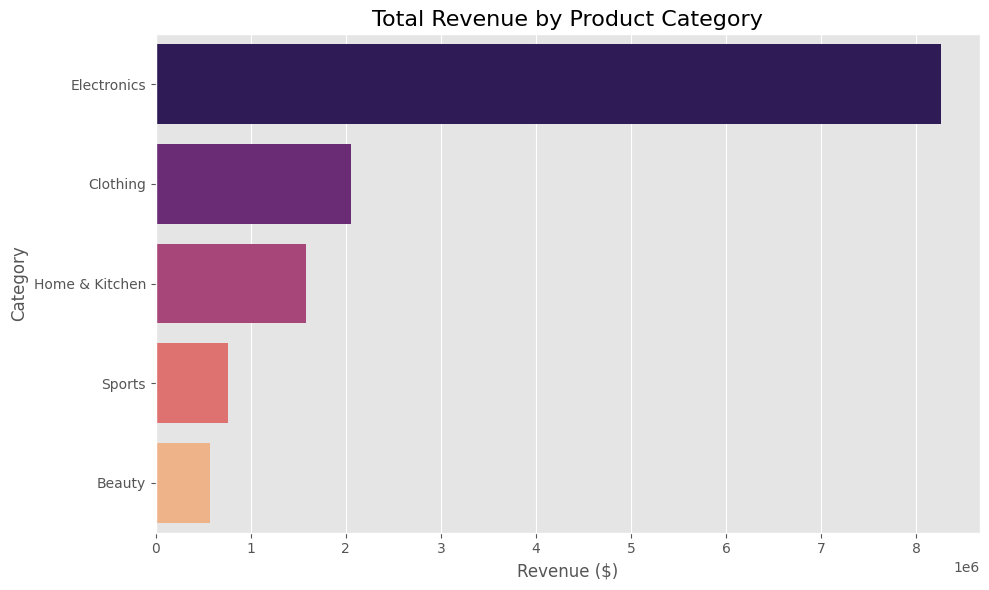

In [4]:
# Create a month-year column for seasonal trends
df_clean['month_year'] = df_clean['timestamp'].dt.to_period('M')

# Only consider purchases for revenue analysis
df_purchases = df_clean[df_clean['event_type'] == 'purchase']

# --- A. Top Revenue-Driving Products (Categories) ---
revenue_by_cat = df_purchases.groupby('category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_cat.values, y=revenue_by_cat.index, palette='magma')
plt.title('Total Revenue by Product Category', fontsize=16)
plt.xlabel('Revenue ($)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

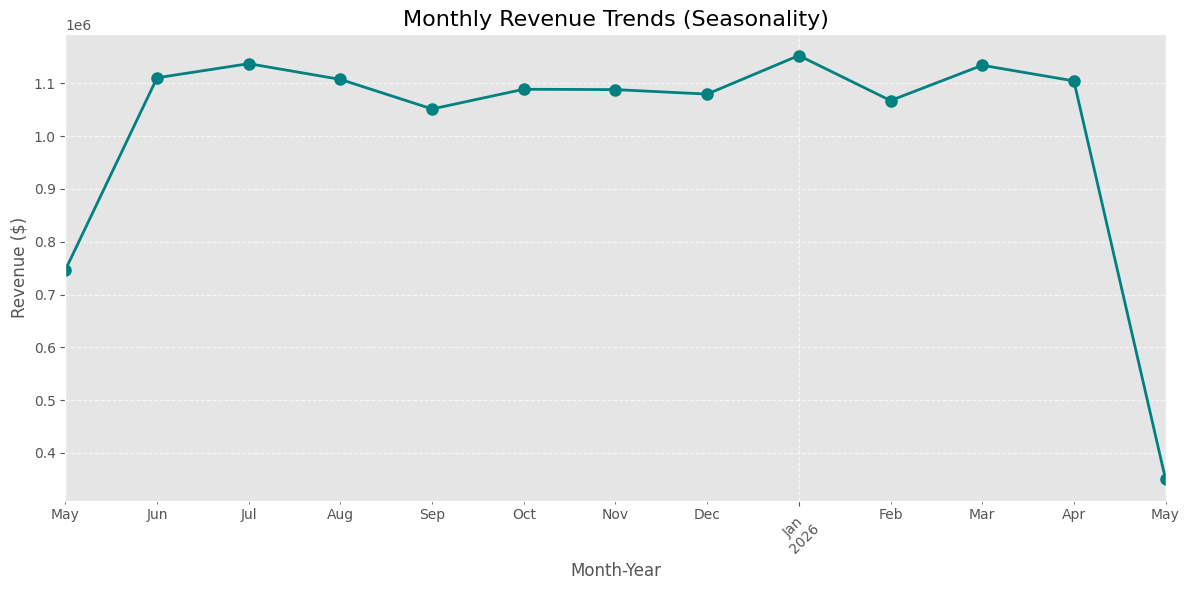

In [5]:
# --- B. Seasonal Trends ---
monthly_revenue = df_purchases.groupby('month_year')['revenue'].sum()

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o', color='teal', linewidth=2, markersize=8)
plt.title('Monthly Revenue Trends (Seasonality)', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

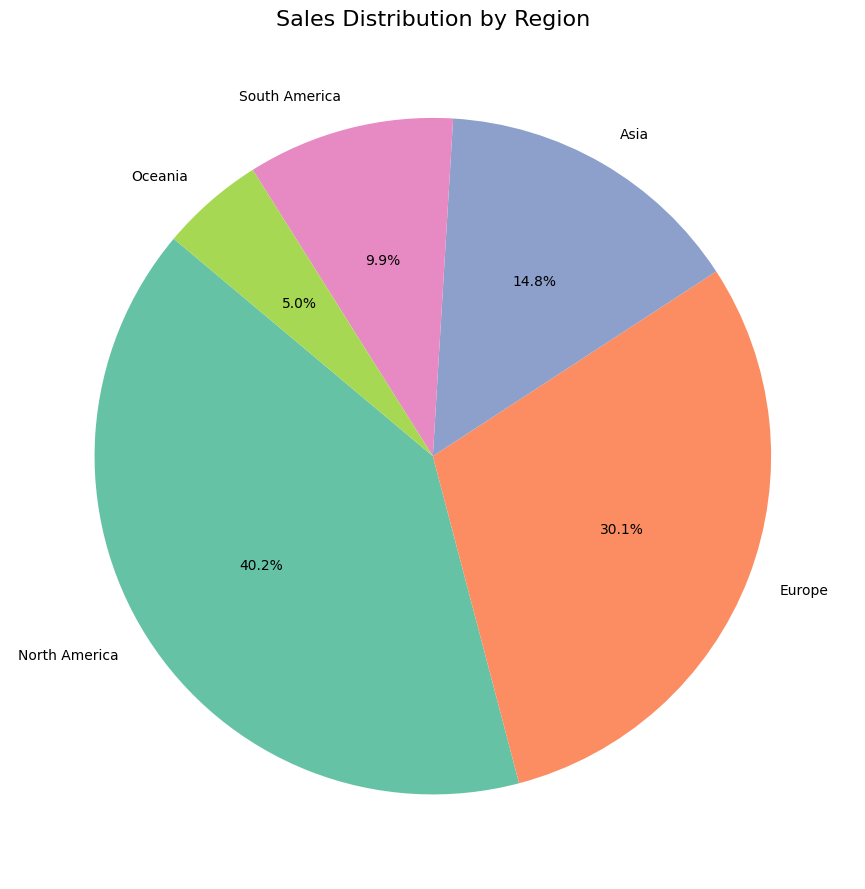

In [6]:
# --- C. Regional Sales Performance ---
revenue_by_region = df_purchases[df_purchases['region'] != 'Unknown'].groupby('region')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 9))
plt.pie(revenue_by_region, labels=revenue_by_region.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set2"))
plt.title('Sales Distribution by Region', fontsize=16)
plt.tight_layout()
plt.show()

Total Views: 337,817
Total Adds to Cart: 130,285
Total Purchases: 51,935
Cart Abandonment Rate: 60.14%


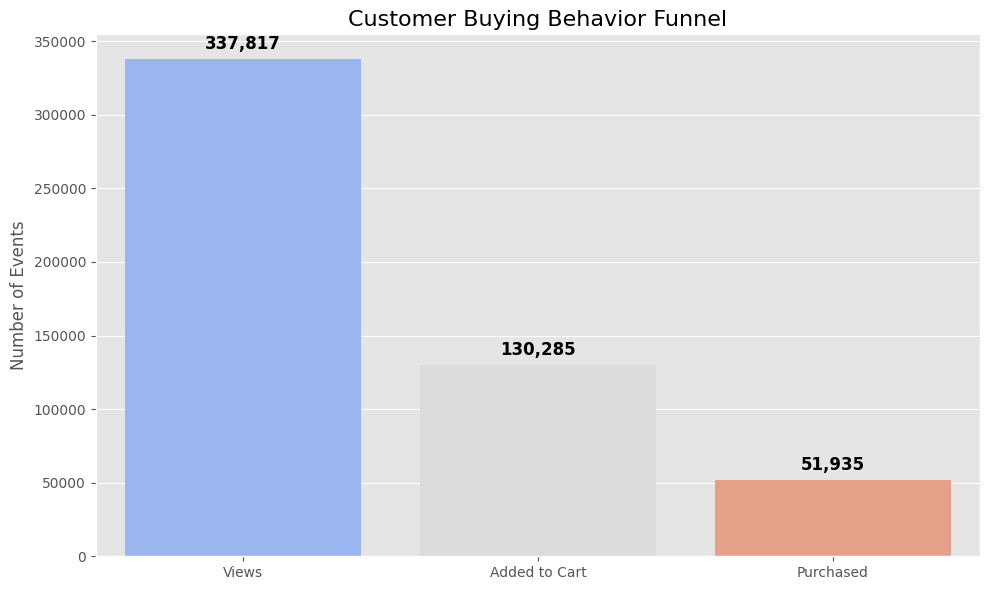

In [7]:
# --- D. Customer Buying Behavior & Cart Abandonment Patterns ---
# Calculate funnel metrics
funnel_counts = df_clean['event_type'].value_counts()
views = funnel_counts.get('view', 0)
carts = funnel_counts.get('cart', 0)
purchases = funnel_counts.get('purchase', 0)

cart_abandonment_rate = (carts - purchases) / carts * 100 if carts > 0 else 0

print(f"Total Views: {views:,}")
print(f"Total Adds to Cart: {carts:,}")
print(f"Total Purchases: {purchases:,}")
print(f"Cart Abandonment Rate: {cart_abandonment_rate:.2f}%")

# Visualize the funnel
plt.figure(figsize=(10, 6))
funnel_stages = ['Views', 'Added to Cart', 'Purchased']
funnel_values = [views, carts, purchases]

ax = sns.barplot(x=funnel_stages, y=funnel_values, palette='coolwarm')
plt.title('Customer Buying Behavior Funnel', fontsize=16)
plt.ylabel('Number of Events', fontsize=12)

# Add text labels on bars
for i, v in enumerate(funnel_values):
    ax.text(i, v + (views*0.02), f'{v:,}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()